In [94]:
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter
import emoji

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

# Modelagem
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from textblob import TextBlob
from deep_translator import GoogleTranslator

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud



In [95]:

# Downloads necessários
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('rslp', quiet=True)

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [96]:

print("="*70)
print("📊 ANÁLISE DE DADOS NÃO ESTRUTURADOS - INSTAGRAM")
print("="*70)

df = pd.read_csv('dados/trusted/dataset_comentarios_com_posts.csv')
print(f"\n✅ Dataset carregado: {len(df)} linhas")
print(f"📋 Colunas: {list(df.columns)}")

# Trabalhar com os comentários
textos_originais = df['comment_text'].dropna().tolist()
print(f"\n💬 Total de comentários para análise: {len(textos_originais)}")



📊 ANÁLISE DE DADOS NÃO ESTRUTURADOS - INSTAGRAM

✅ Dataset carregado: 56 linhas
📋 Colunas: ['post_url', 'post_caption', 'post_owner_full_name', 'post_owner_username', 'post_likes_count', 'post_comments_count', 'post_timestamp', 'post_first_comment', 'comment_id', 'comment_text', 'comment_timestamp', 'comment_owner_profile_pic']

💬 Total de comentários para análise: 56


In [97]:

print("\n" + "="*70)
print("🧹 ETAPA 1: LIMPEZA BÁSICA")
print("="*70)

def limpar_basico(texto):
    """Remove pontuações e quebras de linha, mantém emojis temporariamente"""
    if pd.isna(texto):
        return ""
    
    # Converter para string
    texto = str(texto)
    
    # Substituir quebras de linha por espaço
    texto = texto.replace('\n', ' ').replace('\r', ' ')
    
    # Remover pontuações (mas manter emojis)
    # Remove apenas pontuação ASCII
    texto = re.sub(r'[^\w\s\U0001F300-\U0001F9FF]', ' ', texto)
    
    # Remove espaços múltiplos
    texto = ' '.join(texto.split())
    
    return texto

def remover_acentos(texto):
    """Remove acentuação"""
    nfkd = unicodedata.normalize('NFKD', texto)
    return ''.join([c for c in nfkd if not unicodedata.combining(c)])

# Aplicar limpeza básica
textos_limpos = [limpar_basico(t) for t in textos_originais]
textos_limpos = [t.lower() for t in textos_limpos]  # Minúsculas
textos_limpos = [remover_acentos(t) for t in textos_limpos]  # Sem acentos

print(f"✅ Limpeza básica concluída")
print(f"\nExemplo de transformação:")
print(f"Original: {textos_originais[0][:80]}")
print(f"Limpo: {textos_limpos[0][:80]}")



🧹 ETAPA 1: LIMPEZA BÁSICA
✅ Limpeza básica concluída

Exemplo de transformação:
Original: Ameeiiii
Limpo: ameeiiii


In [98]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import emoji
from collections import Counter

print("\n" + "="*70)
print("😊 ETAPA 2: ANÁLISE DETALHADA DE EMOJIS (100% PLOTLY)")
print("="*70)

def extrair_emojis(texto):
    """Extrai todos os emojis de um texto"""
    return [c for c in texto if c in emoji.EMOJI_DATA]

def contar_palavras(texto):
    """Conta palavras (sem emojis)"""
    texto_sem_emoji = ''.join([c for c in texto if c not in emoji.EMOJI_DATA])
    return len(texto_sem_emoji.split())

# --- 1. Processamento dos Dados ---
# Certifique-se de que a lista 'textos_limpos' já existe no seu ambiente anterior
emojis_por_comentario = [extrair_emojis(t) for t in textos_limpos]
todos_emojis = [e for lista in emojis_por_comentario for e in lista]

# Estatísticas
comentarios_com_emoji = sum(1 for e in emojis_por_comentario if len(e) > 0)
total_emojis = len(todos_emojis)
emojis_unicos = len(set(todos_emojis))

# Emojis mais usados (Counter)
emoji_counter = Counter(todos_emojis)
top_emojis = emoji_counter.most_common(20)

# Palavras vs Emojis
total_palavras = sum(contar_palavras(t) for t in textos_limpos)
emojis_contagem = [len(e) for e in emojis_por_comentario]

# --- 2. Detetive de Emojis (Para resolver o problema do 5º lugar) ---
print(f"\n🕵️ DETETIVE DE EMOJIS:")
if len(top_emojis) >= 5:
    emoji_problematico = top_emojis[4] # Índice 4 é o 5º lugar
    char = emoji_problematico[0]
    
    print(f"   • O 5º emoji é: {char}")
    print(f"   • Nome (Demojize): {emoji.demojize(char)}")
    print(f"   • Código Unicode: {ascii(char)}")
    print("   -> Se este emoji estiver quebrando o gráfico, tente substituí-lo na lista 'top_emojis' ou atualizar sua fonte.")
else:
    print("   • Menos de 5 emojis encontrados, impossível verificar o 5º lugar.")

# --- 3. Exibir Estatísticas no Console ---
print(f"\n📊 ESTATÍSTICAS GERAIS:")
print(f"   • Total de emojis: {total_emojis}")
print(f"   • Emojis únicos: {emojis_unicos}")
print(f"   • Média de emojis por comentário: {np.mean(emojis_contagem):.2f}")

print(f"\n🏆 TOP 10 EMOJIS MAIS USADOS:")
for i, (emoji_char, count) in enumerate(top_emojis[:10], 1):
    porcentagem = (count / total_emojis) * 100
    # Usar demojize para garantir que você saiba o nome se o print falhar
    print(f"   {i}. {emoji_char} ({emoji.demojize(emoji_char)}) - {count} vezes ({porcentagem:.1f}%)")

# --- 4. Visualização 1: Histograma (Agora com Plotly) ---
df_hist = pd.DataFrame({'Qtd_Emojis': emojis_contagem})
media_emojis = np.mean(emojis_contagem)

fig_hist = px.histogram(df_hist, x='Qtd_Emojis', 
                        nbins=20,
                        title='Distribuição de Emojis por Comentário',
                        labels={'Qtd_Emojis': 'Número de Emojis', 'count': 'Frequência'},
                        color_discrete_sequence=['#636EFA']) # Cor azul padrão do Plotly

# Adicionar linha da média
fig_hist.add_vline(x=media_emojis, line_dash="dash", line_color="red",
                   annotation_text=f"Média: {media_emojis:.2f}", 
                   annotation_position="top right")

fig_hist.update_layout(bargap=0.1, height=400)
fig_hist.show()

# --- 5. Visualização 2: Top 10 Emojis (Plotly) ---
df_top10 = pd.DataFrame(top_emojis[:10], columns=['Emoji', 'Contagem'])

fig_bar = px.bar(df_top10, 
             x='Contagem', 
             y='Emoji', 
             orientation='h',
             title='Top 10 Emojis Mais Usados',
             text='Contagem',
             color='Contagem', 
             color_continuous_scale='Blues')

fig_bar.update_layout(
    yaxis={'categoryorder':'total ascending'}, 
    font=dict(size=18),
    height=500
)
fig_bar.update_traces(textposition='outside')
fig_bar.show()

# --- 6. Salvar CSV ---
df_emojis = pd.DataFrame({
    'emoji': [e[0] for e in top_emojis],
    'nome': [emoji.demojize(e[0]) for e in top_emojis], # Adicionei o nome para facilitar a identificação
    'quantidade': [e[1] for e in top_emojis],
    'porcentagem': [(e[1]/total_emojis)*100 for e in top_emojis]
})
df_emojis.to_csv('dados/results/analise_emojis_detalhada.csv', index=False)
print(f"\n✅ Análise salva em: dados/results/analise_emojis_detalhada.csv")


😊 ETAPA 2: ANÁLISE DETALHADA DE EMOJIS (100% PLOTLY)

🕵️ DETETIVE DE EMOJIS:
   • O 5º emoji é: 🙏
   • Nome (Demojize): :folded_hands:
   • Código Unicode: '\U0001f64f'
   -> Se este emoji estiver quebrando o gráfico, tente substituí-lo na lista 'top_emojis' ou atualizar sua fonte.

📊 ESTATÍSTICAS GERAIS:
   • Total de emojis: 125
   • Emojis únicos: 9
   • Média de emojis por comentário: 2.23

🏆 TOP 10 EMOJIS MAIS USADOS:
   1. 😍 (:smiling_face_with_heart-eyes:) - 47 vezes (37.6%)
   2. 😂 (:face_with_tears_of_joy:) - 25 vezes (20.0%)
   3. 👏 (:clapping_hands:) - 24 vezes (19.2%)
   4. 🔥 (:fire:) - 9 vezes (7.2%)
   5. 🙏 (:folded_hands:) - 5 vezes (4.0%)
   6. 🎊 (:confetti_ball:) - 5 vezes (4.0%)
   7. 🙌 (:raising_hands:) - 5 vezes (4.0%)
   8. 🙋 (:person_raising_hand:) - 4 vezes (3.2%)
   9. 💉 (:syringe:) - 1 vezes (0.8%)



✅ Análise salva em: dados/results/analise_emojis_detalhada.csv


In [99]:
print("\n" + "="*70)
print("🗑️ ETAPA 3: REMOÇÃO DE EMOJIS E NÚMEROS")
print("="*70)

def remover_emojis_numeros(texto):
    """Remove emojis e números"""
    # Remover emojis
    texto = ''.join([c for c in texto if c not in emoji.EMOJI_DATA])
    # Remover números
    texto = re.sub(r'\d+', '', texto)
    # Limpar espaços extras
    texto = ' '.join(texto.split())
    return texto

textos_sem_emoji = [remover_emojis_numeros(t) for t in textos_limpos]

print(f"✅ Emojis e números removidos")
print(f"\nExemplo:")
print(f"Com emoji: {textos_limpos[1][:80]}")
print(f"Sem emoji: {textos_sem_emoji[1][:80]}")



🗑️ ETAPA 3: REMOÇÃO DE EMOJIS E NÚMEROS
✅ Emojis e números removidos

Exemplo:
Com emoji: 😂😂😂😂😂😂😂😂😂😂😂😂
Sem emoji: 


In [100]:

print("\n" + "="*70)
print("✂️ ETAPA 4: TOKENIZAÇÃO")
print("="*70)

def tokenizar(texto):
    """Divide texto em palavras (tokens)"""
    try:
        return word_tokenize(texto, language='portuguese')
    except:
        return texto.split()

textos_tokenizados = [tokenizar(t) for t in textos_sem_emoji]

print(f"✅ Tokenização concluída")
print(f"\nExemplo:")
print(f"Texto: {textos_sem_emoji[10]}")
print(f"Tokens: {textos_tokenizados[10]}")
print(f"\n📊 Média de tokens por comentário: {np.mean([len(t) for t in textos_tokenizados]):.1f}")



✂️ ETAPA 4: TOKENIZAÇÃO
✅ Tokenização concluída

Exemplo:
Texto: parabens meu bem voce merece o mundo
Tokens: ['parabens', 'meu', 'bem', 'voce', 'merece', 'o', 'mundo']

📊 Média de tokens por comentário: 4.3


In [101]:

print("\n" + "="*70)
print("🚫 ETAPA 5: REMOÇÃO DE STOPWORDS")
print("="*70)

def remover_stopwords(tokens):
    """Remove palavras sem significado analítico"""
    stop_words = set(stopwords.words('portuguese'))
    
    # Adicionar stopwords customizadas do contexto de estética
    stop_words.update([
        'pra', 'pro', 'ne', 'ta', 'to', 'la', 'ai', 'mt', 'tbm',
        'kkk', 'kkkk', 'kkkkk', 'rs', 'rsrs', 'haha', 'rsrsrs'
    ])
    
    return [palavra for palavra in tokens 
            if palavra not in stop_words and len(palavra) > 2]

textos_sem_stopwords = [remover_stopwords(t) for t in textos_tokenizados]

print(f"✅ Stopwords removidas")
print(f"\nExemplo:")
print(f"Com stopwords: {textos_tokenizados[10]}")
print(f"Sem stopwords: {textos_sem_stopwords[10]}")



🚫 ETAPA 5: REMOÇÃO DE STOPWORDS
✅ Stopwords removidas

Exemplo:
Com stopwords: ['parabens', 'meu', 'bem', 'voce', 'merece', 'o', 'mundo']
Sem stopwords: ['parabens', 'bem', 'voce', 'merece', 'mundo']


In [102]:

print("\n" + "="*70)
print("🌱 ETAPA 6: LEMATIZAÇÃO/STEMMING")
print("="*70)

def lematizar(tokens):
    """Reduz palavras à forma base"""
    stemmer = RSLPStemmer()
    return [stemmer.stem(palavra) for palavra in tokens]

textos_lematizados = [lematizar(t) for t in textos_sem_stopwords]

print(f"✅ Lematização concluída")
print(f"\nExemplo:")
print(f"Sem lematizar: {textos_sem_stopwords[10]}")
print(f"Lematizado: {textos_lematizados[10]}")

# Preparar textos para modelagem (juntar tokens)
textos_processados = [' '.join(tokens) for tokens in textos_lematizados]

# Salvar dataset processado
df_processado = df.copy()
df_processado['comment_text_clean'] = textos_sem_emoji
df_processado['comment_text_tokens'] = [' '.join(t) for t in textos_tokenizados]
df_processado['comment_text_processed'] = textos_processados
df_processado.to_csv('dados/trusted/dataset_processado.csv', index=False)

print(f"\n✅ Dataset processado salvo em: dados/trusted/dataset_processado.csv")



🌱 ETAPA 6: LEMATIZAÇÃO/STEMMING
✅ Lematização concluída

Exemplo:
Sem lematizar: ['parabens', 'bem', 'voce', 'merece', 'mundo']
Lematizado: ['parab', 'bem', 'voc', 'merec', 'mund']

✅ Dataset processado salvo em: dados/trusted/dataset_processado.csv


In [103]:
# ============================================================
# ETAPA 7: MODELAGEM ANALÍTICA
# ============================================================

print("\n" + "="*70)
print("📊 ETAPA 7: MODELAGEM ANALÍTICA")
print("="*70)

# Filtrar textos vazios
textos_validos = [t for t in textos_processados if len(t.strip()) > 0]
indices_validos = [i for i, t in enumerate(textos_processados) if len(t.strip()) > 0]

print(f"\n📝 Comentários válidos para análise: {len(textos_validos)}")



📊 ETAPA 7: MODELAGEM ANALÍTICA

📝 Comentários válidos para análise: 51



----------------------------------------------------------------------
1️⃣ TF-IDF - TERMOS MAIS IMPORTANTES (VOCABULÁRIO RECONSTRUÍDO)
----------------------------------------------------------------------

🔑 Top 30 termos mais importantes (TF-IDF):
    1. abencoe
    2. amei
    3. amiga
    4. arrasa
    5. cada
    6. conheci
    7. continue
    8. demais
    9. desse
   10. deus
   11. dia
   12. dicas
   13. esteticista
   14. feliz
   15. incrivel
   16. kkkkkkkk
   17. linda
   18. lindaa
   19. maravilhosa
   20. melhor
   21. merece
   22. mundo
   23. orgulho
   24. parabens
   25. princesa
   26. resultado
   27. sucesso
   28. todas
   29. trabalho
   30. voce
✅ Gráfico TF-IDF salvo com palavras corrigidas


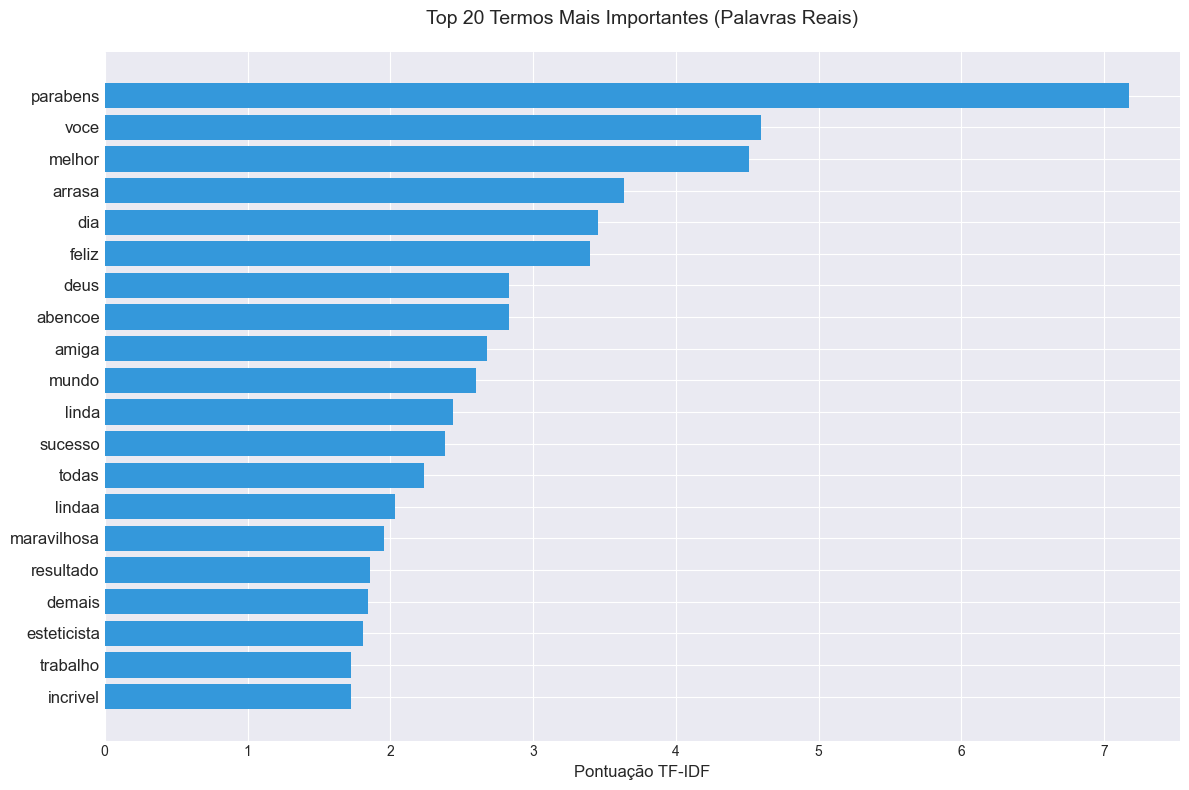

In [104]:
# ----------------------------------------
# 7.1 TF-IDF (COM CORREÇÃO DE PALAVRAS)
# ----------------------------------------
print("\n" + "-"*70)
print("1️⃣ TF-IDF - TERMOS MAIS IMPORTANTES (VOCABULÁRIO RECONSTRUÍDO)")
print("-"*70)

# --- TRUQUE PARA RECUPERAR PALAVRAS ORIGINAIS ---
# 1. Criar um mapeamento: Radical -> Lista de palavras originais
mapa_reverso = {}

# textos_sem_stopwords = lista de tokens originais (da Etapa 5)
# textos_lematizados = lista de tokens cortados (da Etapa 6)
for tokens_orig, tokens_stem in zip(textos_sem_stopwords, textos_lematizados):
    for orig, stem in zip(tokens_orig, tokens_stem):
        if stem not in mapa_reverso:
            mapa_reverso[stem] = []
        mapa_reverso[stem].append(orig)

# 2. Definir a palavra "oficial" para cada radical (a que mais aparece)
from collections import Counter
stem_para_real = {}
for stem, lista_palavras in mapa_reverso.items():
    # Pega a palavra mais comum para representar esse radical
    palavra_mais_comum = Counter(lista_palavras).most_common(1)[0][0]
    stem_para_real[stem] = palavra_mais_comum

# --- FIM DO TRUQUE ---

# Geração do TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=30, min_df=2)
tfidf_matrix = vectorizer_tfidf.fit_transform(textos_validos)
feature_names_stems = vectorizer_tfidf.get_feature_names_out()

# Converter os nomes das features (stems) para palavras reais
feature_names_reais = [stem_para_real.get(stem, stem) for stem in feature_names_stems]

print(f"\n🔑 Top 30 termos mais importantes (TF-IDF):")
for i, palavra in enumerate(feature_names_reais, 1):
    print(f"   {i:2d}. {palavra}")

# Visualização TF-IDF
plt.figure(figsize=(12, 8))
scores = tfidf_matrix.sum(axis=0).A1
indices_top = np.argsort(scores)[-20:][::-1]

# Usar os nomes reais para o gráfico
top_palavras = [feature_names_reais[i] for i in indices_top]
top_scores = [scores[i] for i in indices_top]

# Plotagem com cor para ficar mais agradável
plt.barh(range(len(top_palavras)), top_scores, color='#3498db')
plt.yticks(range(len(top_palavras)), top_palavras, fontsize=12) # Fonte maior
plt.xlabel('Pontuação TF-IDF', fontsize=12)
plt.title('Top 20 Termos Mais Importantes (Palavras Reais)', fontsize=14, pad=20)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('dados/results/tfidf_top_termos.png', dpi=300, bbox_inches='tight')
print(f"✅ Gráfico TF-IDF salvo com palavras corrigidas")


----------------------------------------------------------------------
2️⃣ ANÁLISE DE SENTIMENTO (PT -> EN -> SCORE)
----------------------------------------------------------------------
⏳ Processando sentimentos (isso pode levar alguns segundos devido à tradução)...

😊 DISTRIBUIÇÃO DE SENTIMENTOS:
   Neutro: 20 (35.7%)
   Positivo: 35 (62.5%)
   Negativo: 1 (1.8%)
✅ Gráfico de sentimento salvo


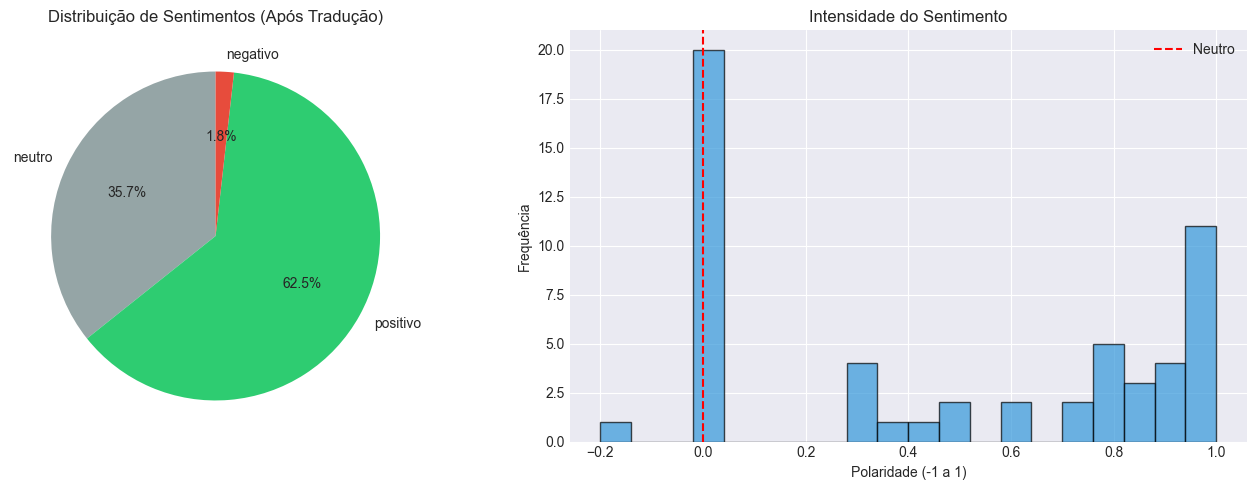

In [105]:
# ----------------------------------------
# 7.2 ANÁLISE DE SENTIMENTO (COM TRADUÇÃO)
# ----------------------------------------
print("\n" + "-"*70)
print("2️⃣ ANÁLISE DE SENTIMENTO (PT -> EN -> SCORE)")
print("-"*70)

# Inicializa o tradutor
tradutor = GoogleTranslator(source='pt', target='en')

def analisar_sentimento(texto):
    """Traduz para EN e classifica sentimento"""
    if not texto or len(str(texto).strip()) == 0:
        return 'neutro', 0.0
    
    try:
        # 1. Traduzir para inglês (TextBlob funciona melhor em EN)
        # Emojis são preservados na tradução
        texto_en = tradutor.translate(texto)
        
        # 2. Analisar o texto traduzido
        blob = TextBlob(texto_en)
        polaridade = blob.sentiment.polarity
        
        # Ajuste de sensibilidade (social media costuma ser intenso)
        if polaridade > 0.05: # Baixei um pouco a régua para captar mais positivos
            return 'positivo', polaridade
        elif polaridade < -0.05:
            return 'negativo', polaridade
        else:
            return 'neutro', polaridade
    except Exception as e:
        # Se der erro na tradução (ex: só tem emoji), tenta analisar direto
        try:
            blob = TextBlob(texto)
            if blob.sentiment.polarity != 0:
                return ('positivo' if blob.sentiment.polarity > 0 else 'negativo'), blob.sentiment.polarity
        except:
            pass
        return 'neutro', 0.0

print("⏳ Processando sentimentos (isso pode levar alguns segundos devido à tradução)...")

sentimentos = []
polaridades = []

# Usar um contador para mostrar progresso se quiser, ou apenas rodar
for i, texto_orig in enumerate(textos_originais):
    sent, pol = analisar_sentimento(texto_orig)
    sentimentos.append(sent)
    polaridades.append(pol)

# Estatísticas
sent_counter = Counter(sentimentos)
print(f"\n😊 DISTRIBUIÇÃO DE SENTIMENTOS:")
for sent, count in sent_counter.items():
    porcentagem = (count / len(sentimentos)) * 100
    print(f"   {sent.capitalize()}: {count} ({porcentagem:.1f}%)")

# --- Visualização ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pizza
cores_map = {'positivo': '#2ecc71', 'neutro': '#95a5a6', 'negativo': '#e74c3c'}
cores = [cores_map.get(x, '#333333') for x in sent_counter.keys()]

axes[0].pie(sent_counter.values(), labels=sent_counter.keys(), autopct='%1.1f%%',
            colors=cores, startangle=90)
axes[0].set_title('Distribuição de Sentimentos (Após Tradução)')

# Histograma de polaridade
axes[1].hist(polaridades, bins=20, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].axvline(0, color='red', linestyle='--', label='Neutro')
axes[1].set_xlabel('Polaridade (-1 a 1)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Intensidade do Sentimento')
axes[1].legend()

plt.tight_layout()
plt.savefig('dados/results/analise_sentimento.png', dpi=300, bbox_inches='tight')
print(f"✅ Gráfico de sentimento salvo")

In [106]:

# ----------------------------------------
# 7.3 CLUSTERING
# ----------------------------------------
print("\n" + "-"*70)
print("3️⃣ CLUSTERING (K-MEANS)")
print("-"*70)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

cluster_counter = Counter(clusters)
print(f"\n📦 DISTRIBUIÇÃO POR CLUSTER:")
for cluster_id in range(n_clusters):
    count = cluster_counter[cluster_id]
    porcentagem = (count / len(clusters)) * 100
    print(f"   Cluster {cluster_id}: {count} comentários ({porcentagem:.1f}%)")

# Mostrar exemplos de cada cluster
print(f"\n📝 EXEMPLOS DE CADA CLUSTER:")
for cluster_id in range(n_clusters):
    indices_cluster = [i for i, c in enumerate(clusters) if c == cluster_id]
    if indices_cluster:
        # Pegar exemplo mais próximo do centróide
        idx_exemplo = indices_cluster[0]
        idx_real = indices_validos[idx_exemplo]
        exemplo = textos_originais[idx_real][:100]
        print(f"\n   Cluster {cluster_id}: '{exemplo}...'")
        




----------------------------------------------------------------------
3️⃣ CLUSTERING (K-MEANS)
----------------------------------------------------------------------

📦 DISTRIBUIÇÃO POR CLUSTER:
   Cluster 0: 40 comentários (78.4%)
   Cluster 1: 6 comentários (11.8%)
   Cluster 2: 5 comentários (9.8%)

📝 EXEMPLOS DE CADA CLUSTER:

   Cluster 0: 'Ameeiiii...'

   Cluster 1: 'A melhor 😍❤️...'

   Cluster 2: 'Feliz dia para a maior que temosssss 🔥🔥🔥❤️...'



----------------------------------------------------------------------
4️⃣ WORD CLOUD (COM PALAVRAS ORIGINAIS)
----------------------------------------------------------------------
✅ Word Cloud salva com palavras inteiras


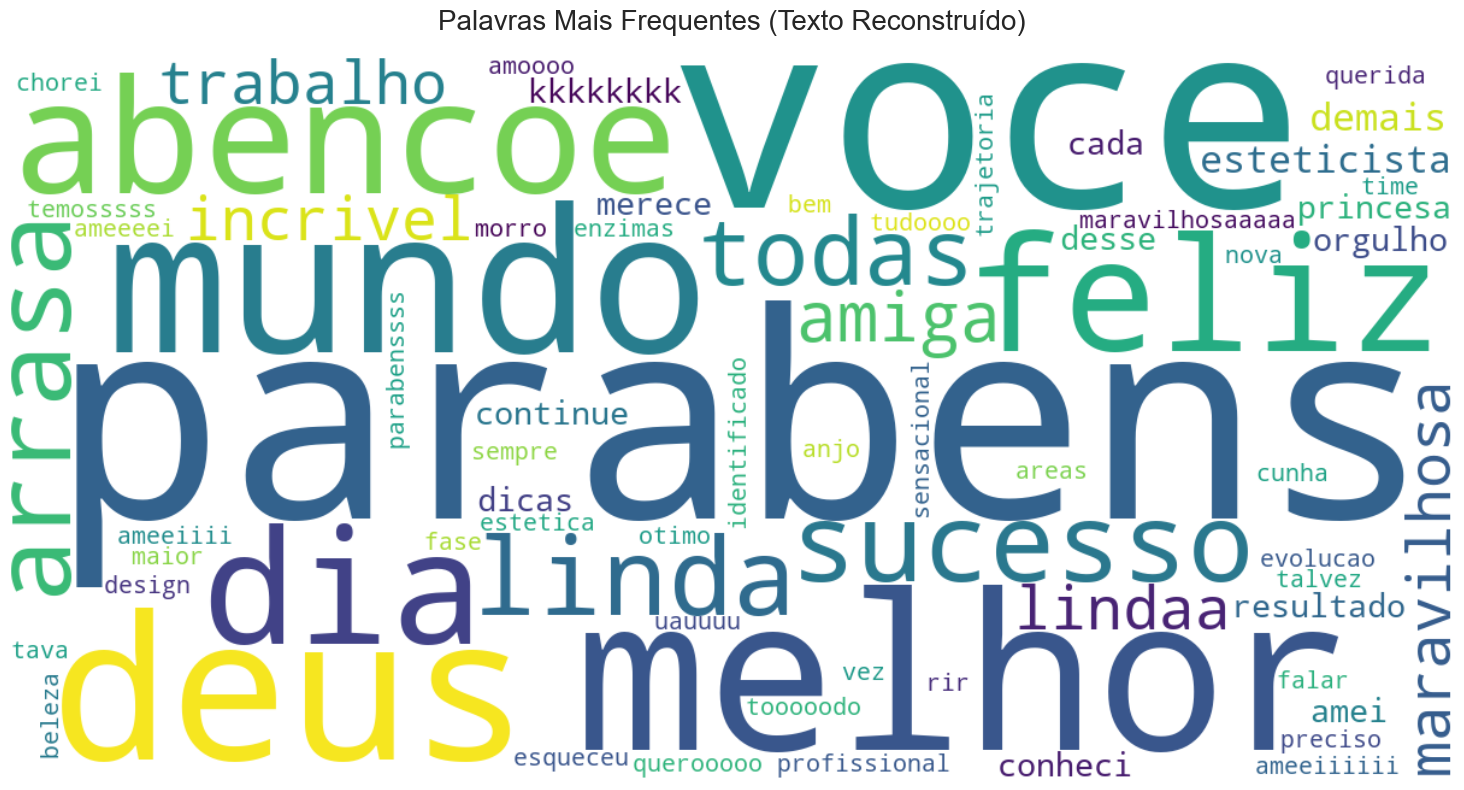

In [107]:
print("\n" + "-"*70)
print("4️⃣ WORD CLOUD (COM PALAVRAS ORIGINAIS)")
print("-"*70)


# --- TRUQUE PARA RECUPERAR PALAVRAS ORIGINAIS ---
# 1. Criar um mapeamento: Radical -> Lista de palavras originais
# Usamos as listas geradas nas etapas anteriores (5 e 6)
mapa_reverso = {}

if 'textos_sem_stopwords' in locals() and 'textos_lematizados' in locals():
    for tokens_orig, tokens_stem in zip(textos_sem_stopwords, textos_lematizados):
        for orig, stem in zip(tokens_orig, tokens_stem):
            if stem not in mapa_reverso:
                mapa_reverso[stem] = []
            mapa_reverso[stem].append(orig)

    # 2. Definir a palavra "oficial" para cada radical (a que mais aparece)
    stem_para_real = {}
    for stem, lista_palavras in mapa_reverso.items():
        # Pega a palavra mais comum para representar esse radical (ex: 'parab' -> 'parabens')
        palavra_mais_comum = Counter(lista_palavras).most_common(1)[0][0]
        stem_para_real[stem] = palavra_mais_comum
else:
    print("⚠️ Atenção: Variáveis 'textos_sem_stopwords' não encontradas. Usando texto lematizado padrão.")
    stem_para_real = {}

# --- RECONSTRUÇÃO DO TEXTO PARA A NUVEM ---
# Transformamos a lista de textos lematizados ('textos_validos') de volta para palavras reais
lista_texto_reconstruido = []

for frase_stem in textos_validos:
    palavras_stem = frase_stem.split()
    # Traduz cada palavra cortada de volta para a original usando o dicionário
    palavras_reais = [stem_para_real.get(word, word) for word in palavras_stem]
    lista_texto_reconstruido.append(' '.join(palavras_reais))

# Junta tudo em uma única string gigante para a WordCloud
texto_completo_real = ' '.join(lista_texto_reconstruido)

# --- GERAÇÃO DA WORD CLOUD ---
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    collocations=False # Define como False para evitar duplicar palavras (ex: "parabens parabens")
).generate(texto_completo_real)

# Visualização
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palavras Mais Frequentes (Texto Reconstruído)', fontsize=20, pad=20)
plt.tight_layout()
plt.savefig('dados/results/wordcloud.png', dpi=300, bbox_inches='tight')
print(f"✅ Word Cloud salva com palavras inteiras")

In [108]:
print("\n" + "-"*70)
print("5️⃣ TOPIC MODELING (LDA)")
print("-"*70)

n_topics = 3
vectorizer_count = CountVectorizer(max_features=50, min_df=2)
doc_term_matrix = vectorizer_count.fit_transform(textos_validos)
feature_names_lda = vectorizer_count.get_feature_names_out()

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(doc_term_matrix)

print(f"\n📚 {n_topics} TÓPICOS IDENTIFICADOS:")
n_top_words = 10
for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-n_top_words:][::-1]
    top_words = [feature_names_lda[i] for i in top_indices]
    print(f"\n   Tópico {topic_idx}: {', '.join(top_words)}")

# ==========


----------------------------------------------------------------------
5️⃣ TOPIC MODELING (LDA)
----------------------------------------------------------------------

📚 3 TÓPICOS IDENTIFICADOS:

   Tópico 0: voc, parab, arras, amig, linda, demal, mund, sucess, merec, orgulh

   Tópico 1: abenco, deu, parab, lind, tod, sucess, continu, ame, dic, kkkkkkkk

   Tópico 2: melhor, feliz, dia, estetic, incri, trabalh, dess, conhec, mund, tod


In [109]:

print("\n" + "="*70)
print("📈 ETAPA 8: RESUMO DOS RESULTADOS")
print("="*70)

# Criar DataFrame com todos os resultados
df_resultados = pd.DataFrame({
    'comment_text_original': textos_originais,
    'comment_text_processed': [textos_processados[i] if i < len(textos_processados) else '' 
                               for i in range(len(textos_originais))],
    'num_palavras': [len(t.split()) for t in textos_sem_emoji],
    'num_emojis': emojis_contagem,
    'sentimento': sentimentos,
    'polaridade': polaridades
})

# Adicionar clusters (só para os válidos)
df_resultados['cluster'] = -1
for i, idx in enumerate(indices_validos):
    df_resultados.loc[idx, 'cluster'] = clusters[i]

print(f"\n📊 ESTATÍSTICAS FINAIS:")
print(f"   • Total de comentários analisados: {len(df_resultados)}")
print(f"   • Média de palavras por comentário: {df_resultados['num_palavras'].mean():.1f}")
print(f"   • Média de emojis por comentário: {df_resultados['num_emojis'].mean():.2f}")
print(f"   • Sentimento predominante: {sent_counter.most_common(1)[0][0]}")
print(f"   • Comentários positivos: {sent_counter['positivo']} ({sent_counter['positivo']/len(sentimentos)*100:.1f}%)")
print(f"   • Comentários negativos: {sent_counter['negativo']} ({sent_counter['negativo']/len(sentimentos)*100:.1f}%)")

# Salvar resultados finais
df_resultados.to_csv('dados/results/analise_completa.csv', index=False)
print(f"\n✅ Resultados completos salvos em: dados/results/analise_completa.csv")

# Criar relatório resumido
relatorio = {
    'total_comentarios': len(df_resultados),
    'media_palavras': df_resultados['num_palavras'].mean(),
    'total_emojis': total_emojis,
    'emojis_unicos': emojis_unicos,
    'top_5_emojis': top_emojis[:5],
    'sentimento_positivo_pct': (sent_counter['positivo']/len(sentimentos)*100),
    'sentimento_negativo_pct': (sent_counter['negativo']/len(sentimentos)*100),
    'sentimento_neutro_pct': (sent_counter['neutro']/len(sentimentos)*100),
    'top_10_termos_tfidf': list(feature_names_tfidf[:10]),
    'num_clusters': n_clusters,
    'num_topicos': n_topics
}

import json
with open('dados/results/relatorio_resumido.json', 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, indent=4, ensure_ascii=False)

print("\n" + "="*70)
print("✨ ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*70)
print("\n📁 Arquivos gerados:")
print("   • dados/trusted/dataset_processado.csv")
print("   • dados/results/analise_emojis.png")
print("   • dados/results/analise_emojis_detalhada.csv")
print("   • dados/results/tfidf_top_termos.png")
print("   • dados/results/analise_sentimento.png")
print("   • dados/results/wordcloud.png")
print("   • dados/results/analise_completa.csv")
print("   • dados/results/relatorio_resumido.json")
print("="*70)


📈 ETAPA 8: RESUMO DOS RESULTADOS

📊 ESTATÍSTICAS FINAIS:
   • Total de comentários analisados: 56
   • Média de palavras por comentário: 4.3
   • Média de emojis por comentário: 2.23
   • Sentimento predominante: positivo
   • Comentários positivos: 35 (62.5%)
   • Comentários negativos: 1 (1.8%)

✅ Resultados completos salvos em: dados/results/analise_completa.csv

✨ ANÁLISE CONCLUÍDA COM SUCESSO!

📁 Arquivos gerados:
   • dados/trusted/dataset_processado.csv
   • dados/results/analise_emojis.png
   • dados/results/analise_emojis_detalhada.csv
   • dados/results/tfidf_top_termos.png
   • dados/results/analise_sentimento.png
   • dados/results/wordcloud.png
   • dados/results/analise_completa.csv
   • dados/results/relatorio_resumido.json
